In [7]:
import sympy as sp
from sympy import symbols, integrate, expand, Piecewise

y, eps, h = symbols('y \\epsilon_v h', real=True)

E = eps * h

In [8]:
f1 = Piecewise((- y**2 / (E**2) + 2 * y / E, y < E), (1, True))
f1_devy = f1 / y
f1

Piecewise((2*y/(\epsilon_v*h) - y**2/(\epsilon_v**2*h**2), y < \epsilon_v*h), (1, True))

In [9]:
f0 = f1.integrate(y)
f0


Piecewise((y**2/(\epsilon_v*h) - y**3/(3*\epsilon_v**2*h**2), y < \epsilon_v*h), (-\epsilon_v*h/3 + y, True))

In [10]:
f0_var =  Piecewise((- y**3 / (3*E**2) +  y**2 / E + E/3, y < E), (y, True)) # (y * y) / E - (y * y * y) / (3.0f * E * E) + E / 3.0f
f0_var

Piecewise((\epsilon_v*h/3 + y**2/(\epsilon_v*h) - y**3/(3*\epsilon_v**2*h**2), y < \epsilon_v*h), (y, True))

In [11]:
f2 = sp.diff(f1, y)
f2

Piecewise((2/(\epsilon_v*h) - 2*y/(\epsilon_v**2*h**2), y < \epsilon_v*h), (0, True))

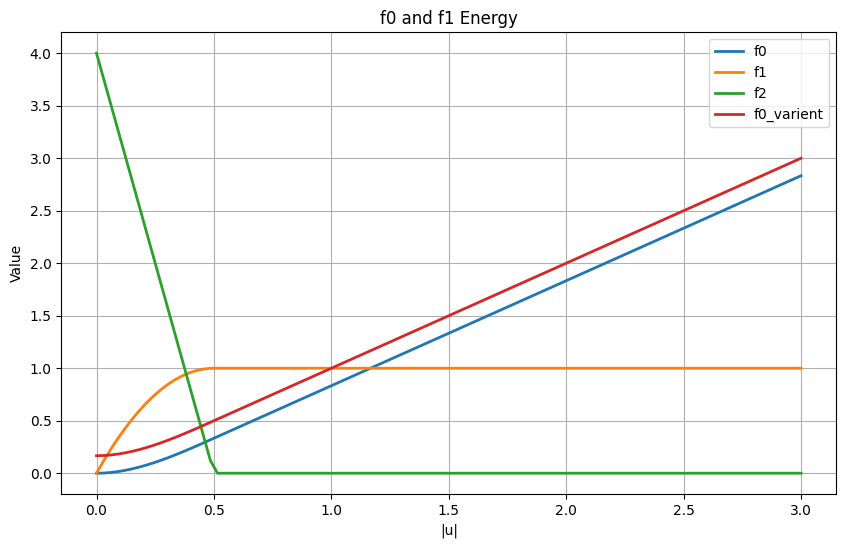

In [12]:
import numpy as np

import matplotlib.pyplot as plt

# Create numerical values for y: relative displacement in tangent space of two elements
y_plot = np.linspace(0, 3, 100)
y_vals = np.abs(y_plot) # since we are dealing with |u|

# Set parameter values
eps_val = 0.5
h_val = 1

# Convert sympy expressions to numpy functions
f0_func = sp.lambdify(y, f0.subs([(eps, eps_val), (h, h_val)]), 'numpy')
f1_func = sp.lambdify(y, f1.subs([(eps, eps_val), (h, h_val)]), 'numpy')
f2_func = sp.lambdify(y, f2.subs([(eps, eps_val), (h, h_val)]), 'numpy')
f0_var_func = sp.lambdify(y, f0_var.subs([(eps, eps_val), (h, h_val)]), 'numpy')

# Calculate values
f0_vals = f0_func(y_vals)
f1_vals = f1_func(y_vals)
f2_vals = f2_func(y_vals)
f0_var_vals = f0_var_func(y_vals)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(y_plot, f0_vals, label='f0', linewidth=2)
plt.plot(y_plot, f1_vals, label='f1', linewidth=2)
plt.plot(y_plot, f2_vals, label='f2', linewidth=2)
plt.plot(y_plot, f0_var_vals, label='f0_varient', linewidth=2)
plt.xlabel('|u|')
plt.ylabel('Value')
plt.title('f0 and f1 Energy')
plt.legend()
plt.grid(True)
plt.show()

For each VF and EE pairs, we have 4 vertices. Given the **current position** $x_i$ and the **initial position** at the begginning of this frame $X_i$, then we have the delta vector 

$$t = \sum_i^4 w_i x_i$$

Where $w_i$ is the weight of each vertices (e.g., $w_2$ to $w_4$ is the negative barycentic coordinate $c_i$ of the projection point on the triangle). Also the distance can be calculated as $d = |t|$, and contact direction is $n=t/d$. The delta vector in the initial state is $t_0 = \sum_i^4 W_i X_i$.

We calculate the relative displacement $\Delta x = t-t_0$ in the tangent space of contact plane as:

$$ u = \Delta x - n^T \Delta x n = (\mathbf{I}_{3\times 3} - nn^T) \Delta x = P \Delta x $$

Where $P = \mathbf{I}_{3\times 3} - nn^T$ is the projection matrix.

Let $s=|u|$ and $\bar{u}=u/s$, then we have:

$$ E = \mu \lambda f_0(s) $$

Where $\lambda = - {\partial b}/{\partial d}$ is the contact force, $b$ is the contact energy (Fefers to [Contact Energy Document](contact_energy.ipynb)). $\mu$ is the friction coefficient (about 0~0.5).

Its derivatives:

$$ 
\begin{aligned}
\frac{\partial E}{\partial x} 
&= \frac{\partial E}{\partial s} \frac{\partial s}{\partial u} \frac{\partial u}{\partial t} \frac{\partial t}{\partial x} \\
&= (\mu \lambda f_1(s)) (\frac{u}{s}) (P) \frac{\partial t}{\partial x}
\end{aligned}
$$

Where:

$$
\frac{\partial t}{\partial x} = \begin{bmatrix} w_1 \mathbf{I}_{3\times 3} & w_2 \mathbf{I}_{3\times 3} & w_3 \mathbf{I}_{3\times 3} & w_4 \mathbf{I}_{3\times 3} \end{bmatrix} \in R^{3\times 12}
$$

Since $u$ is already in the tangent space, so we have $Pu=u$. So for vertex $i$, we have:

$$ \nabla E_{x_i} = \mu \lambda w_i f_1(s) P \bar{u} =  \mu \lambda w_i f_1(s) \bar{u} $$

Its hessians:

$$ 
\begin{aligned}
\nabla E^2_{x_{ij}}
&= \mu \lambda w_i w_j ((f_2(s) - \frac{f_1(s)}{s}) \bar{u} \bar{u}^T + \frac{f_1(s)}{s} P )
\end{aligned}
$$
